In [1]:
# https://medium.com/@RobuRishabh/understanding-and-implementing-faster-r-cnn-248f7b25ff96

In [1]:
import cv2
import random
import numpy as np

Initialization of image
1. kernel size for gausian blur
2. binary threshold
3. box area min, max

# Configuration  

In [ ]:
# ---------------- CONFIG ----------------
class Config:
    Dataset_src = r"D:\Himanshu_ML\TE_UAV Data\TE_defected\cat_defect1_data"
    TRAIN_IMAGE_DIR = Dataset_src + "\train"
    TRAIN_ANNOTATION_PATH = TRAIN_IMAGE_DIR + "_annotations.coco.json"
    VAL_IMAGE_DIR = Dataset_src + "\valid"
    VAL_ANNOTATION_PATH = VAL_IMAGE_DIR + "\_annotations.coco.json"

    NUM_EPOCHS = 50
    BATCH_SIZE = 4
    LR = 1e-4
    WD = 1e-4

    FG_IOU = 0.5
    BG_IOU = 0.3
    BATCH_PER_IMG = 256
    POSITIVE_FRACTION = 0.5
    PRE_NMS_TRAIN = 2000
    PRE_NMS_TEST = 1000
    POST_NMS_TRAIN = 2000
    POST_NMS_TEST = 300
    NMS_THRESH = 0.7


# Preprocessing

In [4]:
from typing import Tuple

In [ ]:
# ---------------- PREPROCESSING ----------------
class Preprocessing:
    """Lightweight preprocessing for defect detection."""
    def __init__(self, use_clahe=True, use_flip=True, use_brightness=True):
        self.use_clahe = use_clahe
        self.use_flip = use_flip
        self.use_brightness = use_brightness

    def __call__(self, img: np.ndarray) -> np.ndarray:
        processed_img = img.copy()

        # CLAHE
        if self.use_clahe:
            lab = cv2.cvtColor(processed_img, cv2.COLOR_BGR2LAB)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            lab[:, :, 0] = clahe.apply(lab[:, :, 0])
            processed_img = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

        # Random horizontal flip
        if self.use_flip and random.random() > 0.5:
            processed_img = cv2.flip(processed_img, 1)

        # Random brightness
        if self.use_brightness:
            factor = 1.0 + (random.random() - 0.5) * 0.2
            processed_img = np.clip(processed_img * factor, 0, 255).astype(np.uint8)

        return processed_img


# CBAM (Channel + Spatial)

In [6]:
import torch
import torchvision
import torch.nn as nn
from torchvision.ops import DeformConv2d

Channel Attention

In [7]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_planes, in_planes // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_planes // reduction, in_planes, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return x * self.sigmoid(self.fc(x))

Spatial Attention

In [8]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel=7):
        super().__init__()
        pad = (kernel - 1) // 2
        self.conv = nn.Conv2d(2, 1, kernel, padding=pad, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        max_, _ = x.max(dim=1, keepdim=True)
        attn = torch.cat([avg, max_], dim=1)
        attn = self.sigmoid(self.conv(attn))
        return x * attn


Channel+Spatial

In [9]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()

    def forward(self, x):
        x = self.ca(x)
        x = self.sa(x)
        return x

# Feature Map (ResNet architecture)

In [10]:
from collections import OrderedDict
import torch.nn.functional as F

In [11]:
class CustomBackboneWithFPN(nn.Module):
    def __init__(self):
        super().__init__()
        base = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
        self.stage1 = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
        self.stage2 = base.layer1
        self.stage3 = base.layer2
        self.stage4 = base.layer3
        self.stage5 = base.layer4

        self.l5 = nn.Conv2d(2048, 256, 1)
        self.l4 = nn.Conv2d(1024, 256, 1)
        self.l3 = nn.Conv2d(512, 256, 1)
        self.l2 = nn.Conv2d(256, 256, 1)

        self.s4 = nn.Conv2d(256, 256, 3, padding=1)
        self.s3 = nn.Conv2d(256, 256, 3, padding=1)
        self.s2 = nn.Conv2d(256, 256, 3, padding=1)

        self.deform = DeformConv2d(256, 256, 3, padding=1)
        self.cbam = CBAM(256)

    def _upsample_add(self, x, y):
        return F.interpolate(x, size=y.shape[-2:], mode='nearest') + y

    def forward(self, x):
        c1 = self.stage1(x)
        c2 = self.stage2(c1)
        c3 = self.stage3(c2)
        c4 = self.stage4(c3)
        c5 = self.stage5(c4)

        p5 = self.l5(c5)
        p4 = self._upsample_add(p5, self.l4(c4))
        p3 = self._upsample_add(p4, self.l3(c3))
        p2 = self._upsample_add(p3, self.l2(c2))

        offset = torch.zeros(
            p5.shape[0], 2 * 3 * 3, p5.shape[2], p5.shape[3],
            device=p5.device, dtype=p5.dtype
        )
        p5 = self.cbam(self.deform(p5, offset))
        p4, p3, p2 = self.s4(p4), self.s3(p3), self.s2(p2)

        return OrderedDict({"0": p2, "1": p3, "2": p4, "3": p5})

# Data Annotation

In [ ]:
import json
from typing import Tuple, List, Dict, Any
import os

In [13]:
def load_coco_data(json_path: str, image_dir: str) -> Tuple[List[Dict[str, Any]], int]:
    """
    Parses a COCO JSON file and structures the data for the custom dataset.
    Returns a list of dictionaries, where each dict contains image path and annotations.
    """
    with open(json_path, 'r') as f:
        coco_data = json.load(f)

    # Map image IDs to file names and category IDs to labels
    id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}
    
    # Store annotations by image ID
    annotations_by_image = {}
    for ann in coco_data['annotations']:
        image_id = ann['image_id']
        if image_id not in annotations_by_image:
            annotations_by_image[image_id] = {'boxes': [], 'labels': []}
        
        # COCO bbox format is [x_min, y_min, width, height]
        # Convert it to [x_min, y_min, x_max, y_max] and store as a list
        bbox = ann['bbox']
        x_min, y_min, width, height = bbox
        annotations_by_image[image_id]['boxes'].append([x_min, y_min, x_min + width, y_min + height])
        annotations_by_image[image_id]['labels'].append(ann['category_id'])

    # Final list of data dictionaries
    dataset_list = []
    for image_id, anns in annotations_by_image.items():
        image_path = os.path.join(image_dir, id_to_filename[image_id])
        dataset_list.append({
            'image_path': image_path,
            'boxes': torch.tensor(anns['boxes'], dtype=torch.float32),
            'labels': torch.tensor(anns['labels'], dtype=torch.int64)
        })
    
    # +1 for the background class
    num_classes = len(coco_data['categories']) + 1 
    return dataset_list, num_classes


# Dataset & Annotation

In [14]:
import os
from torchvision.transforms import functional as TF
from torch.utils.data import Dataset, DataLoader

In [15]:
class DroneDefectDataset(Dataset):
    def __init__(self, data_list: List[Dict[str, Any]], preprocess=None, transforms=None):
        self.data_list = data_list
        self.preprocess = preprocess
        self.transforms = transforms

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        item = self.data_list[idx]
        
        img_path = item['image_path']
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.preprocess:
            processed_img, mask = self.preprocess(cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
            img = cv2.bitwise_and(processed_img, mask)

        if self.transforms:
            # Note: This part needs careful implementation for object detection.
            # A simple `for t in self.transforms: img = t(img)` won't work
            # correctly with bounding boxes. This is a common pitfall.
            pass

        img_tensor = TF.to_tensor(img)

        target = {
            'boxes': item['boxes'],
            'labels': item['labels']
        }
        
        # This is a crucial step to ensure the box format is correct for the model
        if target['boxes'].numel() == 0:
             target['boxes'] = torch.empty((0, 4), dtype=torch.float32)
        if target['labels'].numel() == 0:
             target['labels'] = torch.empty((0,), dtype=torch.int64)
        
        return img_tensor, target

# Model Construction & Training

In [16]:
def collate_fn(batch):
    return tuple(zip(*batch))

Anchor Generator

In [17]:
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator, RPNHead, RegionProposalNetwork
from torchvision.ops import MultiScaleRoIAlign

In [18]:
def build_model(num_classes):
    backbone = CustomBackboneWithFPN()
    backbone.out_channels = 256

    anchor_gen = AnchorGenerator(
        sizes=((32,), (64,), (128,), (256,)),
        aspect_ratios=((0.5, 1.0, 2.0),) * 4
    )
    num_anchors = anchor_gen.num_anchors_per_location()[0]
    rpn_head = RPNHead(256, num_anchors)

    rpn = RegionProposalNetwork(
        anchor_generator=anchor_gen,
        head=rpn_head,
        fg_iou_thresh=Config.FG_IOU,
        bg_iou_thresh=Config.BG_IOU,
        batch_size_per_image=Config.BATCH_PER_IMG,
        positive_fraction=Config.POSITIVE_FRACTION,
        pre_nms_top_n={"training": Config.PRE_NMS_TRAIN, "testing": Config.PRE_NMS_TEST},
        post_nms_top_n={"training": Config.POST_NMS_TRAIN, "testing": Config.POST_NMS_TEST},
        nms_thresh=Config.NMS_THRESH
    )

    roi_pool = MultiScaleRoIAlign(
        featmap_names=["0", "1", "2", "3"],
        output_size=7,
        sampling_ratio=2
    )

    model = FasterRCNN(
        backbone=backbone,
        num_classes=num_classes,
        rpn_anchor_generator=anchor_gen,
        box_roi_pool=roi_pool,
        image_mean=[0.485, 0.456, 0.406],
        image_std=[0.229, 0.224, 0.225]
    )
    model.rpn = rpn
    return model

# Model Training

In [19]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running_loss = 0.0
    for batch_idx, (imgs, targets) in enumerate(loader):
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(imgs, targets)
        loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        
        print(f"Batch {batch_idx+1}/{len(loader)} - Loss: {loss.item():.4f}")

    return running_loss

# Main Fun

In [20]:
import yaml
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [21]:
if __name__ == '__main__':
    from PIL import Image
    cfg = Config()

    # Load COCO annotations for training and validation
    print("Loading training data...")
    train_data_list, num_classes = load_coco_data(cfg.TRAIN_ANNOTATION_PATH, cfg.TRAIN_IMAGE_DIR)
    print("Loading validation data...")
    val_data_list, _ = load_coco_data(cfg.VAL_ANNOTATION_PATH, cfg.VAL_IMAGE_DIR)
    print(f"Total classes detected: {num_classes}")

    # Datasets & loaders
    prep = Preprocessing()
    train_ds = DroneDefectDataset(train_data_list, preprocess=prep)
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE,
                              shuffle=True, collate_fn=collate_fn, num_workers=0)

    # Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = build_model(num_classes)
    model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WD)

    # Train
    for epoch in range(cfg.NUM_EPOCHS):
        loss = train_one_epoch(model, train_loader, optimizer, device)
        print(f"Epoch {epoch+1}/{cfg.NUM_EPOCHS} - Loss: {loss:.4f}")

    # Save
    torch.save(model.state_dict(), 'part_drone_detection.pth')
    print("Model saved as 'part_drone_detection.pth'")

    # Evaluation
    val_ds = DroneDefectDataset(val_data_list, preprocess=prep)
    val_loader = torch.utils.data.DataLoader(
        val_ds, batch_size=1, shuffle=False, collate_fn=collate_fn
    )

    metric = MeanAveragePrecision(iou_type="bbox", box_format="xyxy")
    model.eval()
    
    print("\nStarting evaluation...")
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            preds_raw = model(imgs)
            
            formatted_preds = []
            for pred in preds_raw:
                formatted_preds.append({
                    'boxes': pred['boxes'],
                    'labels': pred['labels'],
                    'scores': pred['scores']
                })
            metric.update(formatted_preds, targets)

    results = metric.compute()
    print("\nEvaluation Results:")
    print("mAP:", results["map"].item())
    print("mAP_50:", results["map_50"].item())
    print("Recall:", results.get("recall", torch.tensor(-1)).item())
    print("Precision:", results.get("precision", torch.tensor(-1)).item())


Loading training data...
Loading validation data...
Total classes detected: 4


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Himanshu/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:02<00:00, 35.6MB/s]


Batch 1/915 - Loss: 2.2800
Batch 2/915 - Loss: 1.7299
Batch 3/915 - Loss: 1.3328
Batch 4/915 - Loss: 1.1984
Batch 5/915 - Loss: 1.1149
Batch 6/915 - Loss: 0.6817
Batch 7/915 - Loss: 1.4039
Batch 8/915 - Loss: 1.0769
Batch 9/915 - Loss: 0.7102
Batch 10/915 - Loss: 0.7004
Batch 11/915 - Loss: 0.6910
Batch 12/915 - Loss: 0.5824
Batch 13/915 - Loss: 0.4441
Batch 14/915 - Loss: 0.5998
Batch 15/915 - Loss: 0.5658
Batch 16/915 - Loss: 1.2138
Batch 17/915 - Loss: 0.3350
Batch 18/915 - Loss: 0.3708
Batch 19/915 - Loss: 0.7432
Batch 20/915 - Loss: 1.7106
Batch 21/915 - Loss: 0.5057
Batch 22/915 - Loss: 2.0140
Batch 23/915 - Loss: 0.6246
Batch 24/915 - Loss: 0.5741
Batch 25/915 - Loss: 0.4520
Batch 26/915 - Loss: 0.4647
Batch 27/915 - Loss: 0.5147
Batch 28/915 - Loss: 0.5329
Batch 29/915 - Loss: 0.3893
Batch 30/915 - Loss: 0.4945
Batch 31/915 - Loss: 0.7001
Batch 32/915 - Loss: 0.4276
Batch 33/915 - Loss: 0.4301
Batch 34/915 - Loss: 1.4240
Batch 35/915 - Loss: 0.7592
Batch 36/915 - Loss: 0.6071
B

# Testing

In [1]:
import torch
import torchvision
from torchvision.transforms import functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
from frcn_bdy import build_model, Config  


mod_pth = r"D:\Himanshu_ML\TE_UAV Projects\TE_1 UAV MRO\UAV_Dft\part_drone_detection.pth"

# same number of classes used in training
num_classes = 4  

# rebuild model with same structure
model = build_model(num_classes)

# load checkpoint
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load(mod_pth, map_location=device))

model.to(device)
model.eval()


C:\Users\TE\AppData\Local\Temp\ipykernel_19408\1164461403.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(mod_pth, map_location=device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): CustomBackboneWithFPN(
    (stage1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    )
    (stage2): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, 

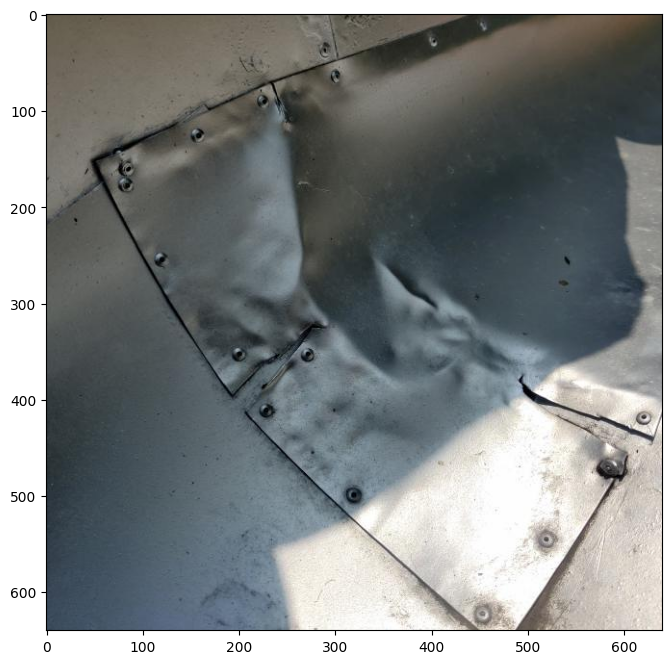

In [3]:
img_path = r"C:\Users\TE\Downloads\Innovation Hangar v2.v2i.coco\train\IMG_20230512_125821_jpg.rf.1682c375988a49aacd68c252cc7725d8.jpg"
image = Image.open(img_path).convert("RGB")
img_tensor = F.to_tensor(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(img_tensor)

boxes = outputs[0]["boxes"].cpu()
labels = outputs[0]["labels"].cpu()
scores = outputs[0]["scores"].cpu()

# Visualization
fig, ax = plt.subplots(1, figsize=(12, 8))
ax.imshow(image)

for box, label, score in zip(boxes, labels, scores):
    if score >= 0.1:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                 linewidth=2, edgecolor='r', facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-10, f"{label.item()} {score:.2f}",
                color='red', fontsize=12,
                bbox=dict(facecolor='yellow', alpha=0.1))
plt.show()